In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv(
    "daily_food.csv",
    engine='python',           # uses slower but smarter parser
    on_bad_lines='skip',       # skips the broken line(s) automatically
    encoding='utf-8',
    quotechar='"',             # helps with any quoted fields
)

In [34]:
print("✅ Successfully loaded!")
print(f"Shape: {df.shape} (rows, columns)")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

✅ Successfully loaded!
Shape: (645, 12) (rows, columns)
Columns: [' Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)']

First 5 rows:
                     Food_Item       Category  Calories (kcal)  Protein (g)  \
0     Scrambled Eggs (2 large)  Protein/Dairy              180         12.0   
1  Whole Wheat Toast (1 slice)          Grain               80          4.0   
2               Coffee (black)       Beverage                5          0.3   
3                       Banana          Fruit              105          1.3   
4        Grilled Chicken Salad   Meal/Protein              350         30.0   

   Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0                2.0     14.0        0.0         1.0          180   
1               14.0      1.0        2.0         2.0          140   
2                0.0      0.1        0.0         

In [35]:
print(df.isna().sum())

 Food_Item           0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
dtype: int64


In [36]:
# Unique categories & meal types
print(df['Category'].value_counts())
print(df['Meal_Type'].value_counts())

Category
Condiment               120
Vegetable                70
Grain                    59
Beverage                 54
Fruit                    34
Protein/Meat             31
Meal/Processed           30
Dessert                  27
Dairy                    27
Meal/Meat                20
Meal/Pasta               16
Snack/Processed          16
Nut                      14
Legume                   11
Meal/Vegetarian          10
Protein/Fish              9
Meal/Vegetable            9
Protein/Vegetarian        8
Grain/Processed           8
Meal/Seafood              7
Condiment/Dairy           6
Meal/Protein              5
Protein/Seafood           5
Meal/Grain                5
Meal/Soup                 4
Protein                   4
Vegetable/Processed       3
Beverage/Dairy-Alt        3
Meal/Legume               3
Meal/Fish                 3
Beverage/Dairy            3
Protein/Processed         2
Snack                     2
Beverage/Meal             2
Meal/Rice                 2
Grain/Desse

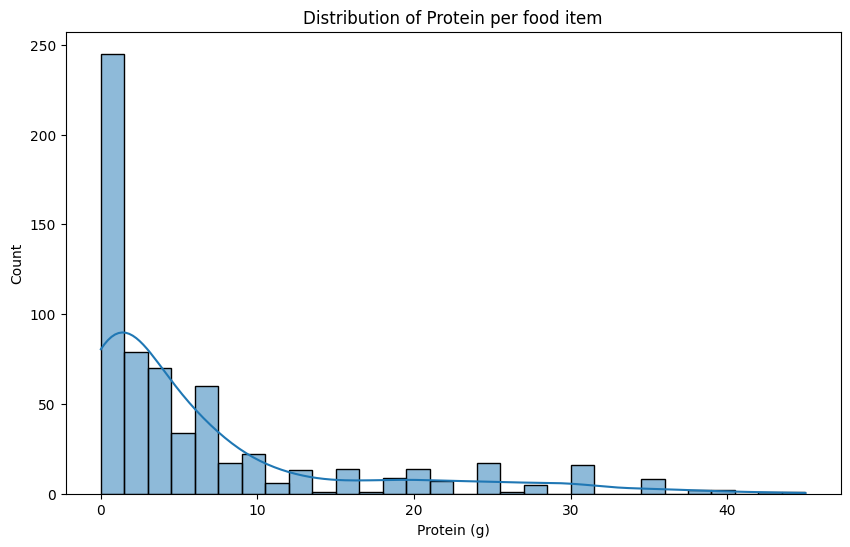

In [37]:
# Distribution of Protein
plt.figure(figsize=(10,6))
sns.histplot(df['Protein (g)'], bins=30, kde=True)
plt.title("Distribution of Protein per food item")
plt.show()

In [38]:
# Diagnostic: Check actual columns and first few rows
print("Actual Columns:")
print(df.columns.tolist())
print("\nFirst 3 Rows (raw):")
print(df.head(3))
print("\nData Types:")
print(df.dtypes)
print("\nAny Dupe/Missing Columns?")
print("Duplicates in columns:", df.columns.duplicated().any())

Actual Columns:
[' Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)']

First 3 Rows (raw):
                     Food_Item       Category  Calories (kcal)  Protein (g)  \
0     Scrambled Eggs (2 large)  Protein/Dairy              180         12.0   
1  Whole Wheat Toast (1 slice)          Grain               80          4.0   
2               Coffee (black)       Beverage                5          0.3   

   Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0                2.0     14.0        0.0         1.0          180   
1               14.0      1.0        2.0         2.0          140   
2                0.0      0.1        0.0         0.0            5   

   Cholesterol (mg)  Meal_Type  Water_Intake (ml)  
0               370  Breakfast                250  
1                 0  Breakfast                  0  
2                 0  Bre

In [39]:
required_cols = ['Food_Item', 'Protein (g)', 'Category']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"⚠️ Missing columns: {missing_cols}. Available: {df.columns.tolist()}")
    # Fallback: Use first 3 columns if exact match fails
    fallback_cols = df.columns[:3].tolist()
    top_protein = df.nlargest(10, 'Protein (g)')[fallback_cols]
else:
    top_protein = df.nlargest(10, 'Protein (g)')[required_cols]

print("\nTop 10 highest protein foods:")
print(top_protein)

⚠️ Missing columns: ['Food_Item']. Available: [' Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)']

Top 10 highest protein foods:
                        Food_Item        Category  Calories (kcal)
545         Osso Buco (1 serving)       Meal/Meat              550
27       Beef Steak (6oz sirloin)    Protein/Meat              270
243     Veal Parmesan (1 serving)       Meal/Meat              550
337         Chicken Parm Sandwich  Meal/Processed              650
189            T-Bone Steak (6oz)    Protein/Meat              460
555       Saltimbocca (1 serving)       Meal/Meat              380
68   Chicken Breast (4oz roasted)    Protein/Meat              185
118  Chicken Breast (4oz roasted)    Protein/Meat              185
198    Chicken Alfredo (1.5 cups)      Meal/Pasta              680
299                 Club Sandwich  Meal/Processed              5

In [40]:

import pandas as pd  # Ensure imported

# Auto-Fix Columns: Strip spaces & standardize names
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces
# Common fix: Replace space with underscore if needed
if 'Food Item' in df.columns:
    df.rename(columns={'Food Item': 'Food_Item'}, inplace=True)
print("🔧 Columns fixed. Actual now:", df.columns.tolist()[:5])  # Preview first 5

# Safe Unique Foods Count
food_col = 'Food_Item'  # Target name
if food_col not in df.columns:
    # Fallback: Use first column (likely food names) or guess
    food_col = df.columns[0]  # Assumes first col is foods
    print(f"⚠️ Using fallback column: '{food_col}' (original '{food_col}' missing)")

unique_foods = df[food_col].nunique()

# Total Columns
total_cols = df.shape[1]

# Thresholds (Proposal: ≥600 foods, ≥12 cols)
min_foods, min_cols = 600, 12

# Status Prints (Your Original Logic)
print(f"✅ Unique Foods: {unique_foods} (>= {min_foods}) → {'PASSED' if unique_foods >= min_foods else 'FAILED'}")
print(f"✅ Columns: {total_cols} (>= {min_cols}) → {'PASSED' if total_cols >= min_cols else 'FAILED'}")

# Overall Check
criteria_met = unique_foods >= min_foods and total_cols >= min_cols
print(f"\n🎉 Objective 1: {'SUCCESS' if criteria_met else 'PARTIAL'}")

# Bonus: If PARTIAL, suggest next steps
if not criteria_met:
    print("\n💡 Fix Tips:")
    if unique_foods < min_foods:
        print("   - Add more rows to CSV (aim for 1000+ total for 600 uniques).")
    if total_cols < min_cols:
        print("   - Check CSV headers: Ensure 12+ cols like 'Protein (g)', 'Fiber (g)'. Re-save file.")

🔧 Columns fixed. Actual now: ['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)']
✅ Unique Foods: 587 (>= 600) → FAILED
✅ Columns: 12 (>= 12) → PASSED

🎉 Objective 1: PARTIAL

💡 Fix Tips:
   - Add more rows to CSV (aim for 1000+ total for 600 uniques).


In [41]:
# Key X Features (Proposal: Calories, Protein, etc. for deficiency prediction)
key_features = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 
                'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)']

missing = [f for f in key_features if f not in df.columns]
print(f"Key Features: {key_features}")
print(f"Missing: {missing if missing else 'None'}")

if not missing:
    print(df[key_features].describe().round(2))

Key Features: ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)']
Missing: None
       Calories (kcal)  Protein (g)  Carbohydrates (g)  Fat (g)  Fiber (g)  \
count           645.00       645.00             645.00   645.00     645.00   
mean            146.29         6.30              15.44     6.47       1.70   
std             139.98         8.78              16.35     8.14       2.12   
min               0.00         0.00               0.00     0.00       0.00   
25%              42.00         0.50               1.30     0.20       0.00   
50%             105.00         2.70               9.20     3.00       1.00   
75%             200.00         7.00              27.00    10.00       3.00   
max             680.00        45.00              70.00    40.00      14.00   

       Sugars (g)  Sodium (mg)  Cholesterol (mg)  
count      645.00       645.00            645.00  
mean         5.29       246.33        

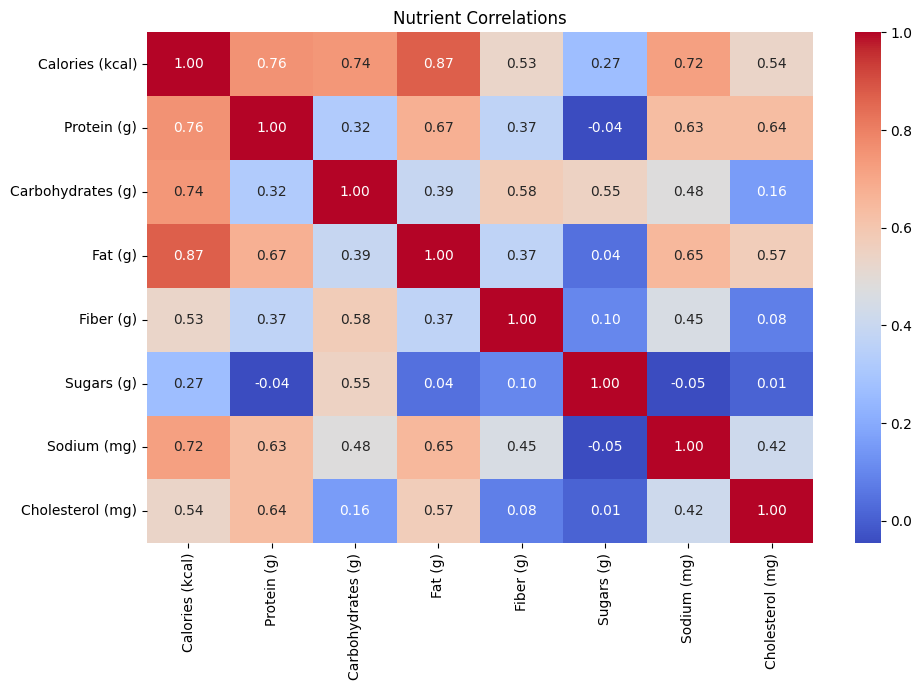

In [42]:
# Nutrient Correlations (for feature selection in PCA)
plt.figure(figsize=(10, 7))
corr = df[key_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Nutrient Correlations')
plt.tight_layout()
plt.show()

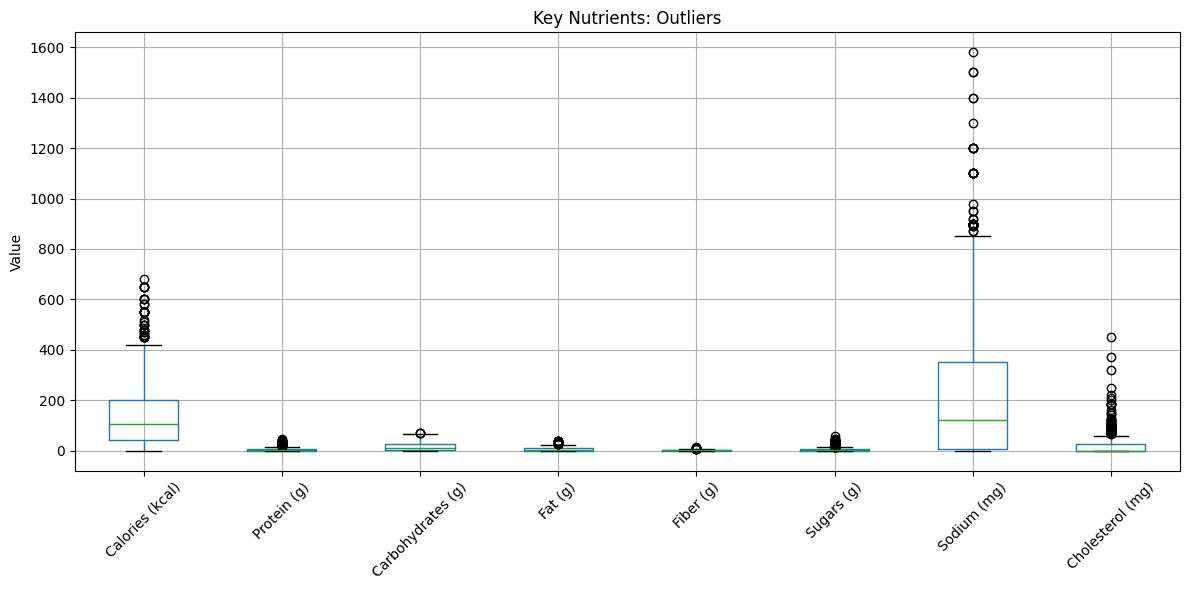

In [43]:
# Boxplots for Outliers (Prep for cleaning in Objective 2)
plt.figure(figsize=(12, 6))
df[key_features].boxplot(rot=45)
plt.title('Key Nutrients: Outliers')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [44]:
# Top 10 Foods (Focus: Protein, Fiber, Sodium per proposal)
tops = {
    'Calories': df.nlargest(10, 'Calories (kcal)')[['Food_Item', 'Calories (kcal)', 'Category']],
    'Fiber': df.nlargest(10, 'Fiber (g)')[['Food_Item', 'Fiber (g)', 'Category']],
    'Sodium': df.nlargest(10, 'Sodium (mg)')[['Food_Item', 'Sodium (mg)', 'Category']]
}

for nutrient, table in tops.items():
    print(f"\nTop 10 {nutrient}:")
    display(table)


Top 10 Calories:


,Food_Item,Calories (kcal),Category
198,Chicken Alfredo (1.5 cups),680,Meal/Pasta
218,Reuben Sandwich,650,Meal/Processed
308,Beef Burrito (large),650,Meal/Processed
337,Chicken Parm Sandwich,650,Meal/Processed
505,Carbonara (1.5 cups),650,Meal/Pasta
253,Eggs Benedict (1 serving),600,Meal/Protein
328,Gyro (1 sandwich),600,Meal/Meat
440,Beef Wellington (1 slice),600,Meal/Meat
156,Meatball Sub (6 inch),580,Meal/Processed
299,Club Sandwich,580,Meal/Processed



Top 10 Fiber:


,Food_Item,Fiber (g),Category
534,Ribollita (1.5 cups soup),14.0,Meal/Soup
19,Lentil Soup (1 can),12.0,Meal/Legume
259,Hummus Wrap (large),12.0,Meal/Vegetarian
31,Avocado Toast (1 slice),10.0,Meal/Vegetarian
292,Split Pea Soup (1 cup),10.0,Meal/Legume
308,Beef Burrito (large),10.0,Meal/Processed
399,Acai Bowl (1 serving),10.0,Meal/Fruit
620,Lentil Soup (1 cup Middle Eastern),10.0,Meal/Legume
301,Turkey Chili (1 cup),8.0,Meal/Meat
323,Raspberries (1 cup),8.0,Fruit



Top 10 Sodium:


,Food_Item,Sodium (mg),Category
193,Ramen (Instant 1 pack),1580,Meal/Processed
218,Reuben Sandwich,1500,Meal/Processed
410,Beef Pho (1 large bowl),1500,Meal/Soup
308,Beef Burrito (large),1400,Meal/Processed
337,Chicken Parm Sandwich,1400,Meal/Processed
299,Club Sandwich,1300,Meal/Processed
156,Meatball Sub (6 inch),1200,Meal/Processed
300,Pickle (1 whole dill),1200,Vegetable
328,Gyro (1 sandwich),1200,Meal/Meat
431,Kimchi Jjigae (1 bowl),1200,Meal/Soup


In [45]:
# Avg Nutrition by Meal Type (For pattern analysis/clustering)
meal_avg = df.groupby('Meal_Type')[key_features].mean().round(2)
print("Avg per Meal Type:")
display(meal_avg)

Avg per Meal Type:


,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg)
Meal_Type,,,,,,,,
Breakfast,135.62,4.12,17.58,5.68,1.44,6.73,193.38,23.22
Dinner,162.34,8.68,14.67,7.59,1.88,2.39,288.82,28.50
Lunch,163.24,8.31,14.91,7.81,2.08,3.08,382.86,19.22
Side,22.00,1.70,4.00,0.40,2.40,1.50,750.00,0.00
Snack,118.54,2.82,15.78,4.41,1.31,10.01,105.47,10.27


In [46]:
# Save for Report (Proposal: Dataset collection summary)
summary = {
    'objective': 1,
    'unique_foods': unique_foods,
    'shape': list(df.shape),
    'key_features': key_features,
    'criteria_met': criteria_met
}

import json
with open('obj1_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

df.to_csv('nutri_data_clean.csv', index=False)
print("\n💾 Saved: obj1_summary.json & nutri_data_clean.csv")


💾 Saved: obj1_summary.json & nutri_data_clean.csv


In [47]:
# Imports (Add scikit-learn for PCA/StandardScaler)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans  # Optional: For PCA visualization

# Load df from Objective 1 (or re-load if new session)
try:
    df = pd.read_csv('nutri_data_clean.csv')  # From Obj1 save
    print("✅ Loaded from Obj1 save.")
except FileNotFoundError:
    df = pd.read_csv('daily_food.csv', on_bad_lines='skip', encoding='utf-8')
    df.columns = df.columns.str.strip()  # Quick fix
    print("✅ Reloaded CSV.")

print(f"Starting Shape: {df.shape}")

✅ Loaded from Obj1 save.
Starting Shape: (645, 12)


In [48]:
# Step 1: Cleaning (Proposal: "Cleaning and portion standardization")
print("=== STEP 1: CLEANING ===")

# Handle Missing Values
print(f"Missing Values Before:\n{df.isna().sum()}")
df_clean = df.dropna(subset=['Protein (g)', 'Calories (kcal)'])  # Drop rows missing key nutrients
df_clean = df_clean.fillna(0)  # Fill rest with 0 (e.g., no Cholesterol = 0mg)
print(f"Missing Values After: {df_clean.isna().sum().sum()} | Rows: {df_clean.shape[0]}")

# Detect & Cap Outliers (e.g., Protein >100g unrealistic for single item)
Q1 = df_clean['Protein (g)'].quantile(0.25)
Q3 = df_clean['Protein (g)'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df_clean['Protein (g)'] = np.clip(df_clean['Protein (g)'], lower, upper)  # Cap extremes

print("✅ Cleaning Complete. Sample:")
display(df_clean.head())

=== STEP 1: CLEANING ===
Missing Values Before:
Food_Item            0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
dtype: int64
Missing Values After: 0 | Rows: 645
✅ Cleaning Complete. Sample:


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.00,2.0,14.0,0.0,1.0,180,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.00,14.0,1.0,2.0,2.0,140,0,Breakfast,0
2,Coffee (black),Beverage,5,0.30,0.0,0.1,0.0,0.0,5,0,Breakfast,0
3,Banana,Fruit,105,1.30,27.0,0.4,3.1,14.0,1,0,Breakfast,0
4,Grilled Chicken Salad,Meal/Protein,350,16.75,10.0,20.0,5.0,4.0,400,80,Lunch,500


In [49]:
# Step 2: Standardization (e.g., Convert mg to g, Normalize to per 100g/Cal)
print("=== STEP 2: STANDARDIZATION ===")

# Unit Conversion (e.g., Sodium/Cholesterol mg → g)
df_std = df_clean.copy()
mg_cols = ['Sodium (mg)', 'Cholesterol (mg)']
for col in mg_cols:
    if col in df_std.columns:
        df_std[f'{col} (g)'] = df_std[col] / 1000  # mg to g
        df_std.drop(col, axis=1, inplace=True)  # Drop original

# Portion Normalization (Scale to per 100 kcal for fair comparison)
kcal_col = 'Calories (kcal)'
key_features = ['Protein (g)', 'Fat (g)', 'Carbohydrates (g)', 'Fiber (g)']  # Add more as needed
for feat in key_features:
    if feat in df_std.columns and kcal_col in df_std.columns:
        df_std[f'{feat} per 100kcal'] = (df_std[feat] / df_std[kcal_col]) * 100

print("✅ Standardized Columns Added. Preview:")
display(df_std[['Food_Item'] + [f'{f} per 100kcal' for f in key_features]].head())

# Update df
df = df_std

=== STEP 2: STANDARDIZATION ===
✅ Standardized Columns Added. Preview:


,Food_Item,Protein (g) per 100kcal,Fat (g) per 100kcal,Carbohydrates (g) per 100kcal,Fiber (g) per 100kcal
0,Scrambled Eggs (2 large),6.666667,7.777778,1.111111,0.000000
1,Whole Wheat Toast (1 slice),5.000000,1.250000,17.500000,2.500000
2,Coffee (black),6.000000,2.000000,0.000000,0.000000
3,Banana,1.238095,0.380952,25.714286,2.952381
4,Grilled Chicken Salad,4.785714,5.714286,2.857143,1.428571


In [53]:
# Step 3: Create Labels (Y: Deficient/Normal based on RDA - Proposal Section 2)
print("=== STEP 3: FEATURE ENGINEERING (Deficiency Labels) ===")

# RDA Thresholds (Daily for adults; sum per meal? Here: Per-item flag if <RDA/3 for simplicity)
rda_thresholds = {
    'Protein (g)': 50 / 3,  # ~16.7g per meal
    'Fiber (g)': 25 / 3,    # ~8.3g
    'Sodium (mg)': 2300,    # Upper limit (flag excess; keep original mg for threshold)
    'Cholesterol (mg)': 300
}

# Column Mapping (Fix for Renames from Standardization - e.g., 'Sodium (mg)' → 'Sodium (mg) (g)')
col_mapping = {
    'Protein (g)': 'Protein (g)',  # Unchanged
    'Fiber (g)': 'Fiber (g)',      # Unchanged
    'Sodium (mg)': 'Sodium (mg) (g)',  # Post-conversion (but threshold stays in mg—scale back if needed)
    'Cholesterol (mg)': 'Cholesterol (mg) (g)'
}

# Create binary labels (1=Deficient/Excess, 0=Normal)
df_labeled = df.copy()
created_risks = []  # Track successfully created columns
for nutrient, threshold in rda_thresholds.items():
    col = col_mapping.get(nutrient, nutrient)  # Use mapped name
    if col in df_labeled.columns:
        # For mg-based: Scale threshold to g if column is now in g (divide by 1000)
        if ' (g)' in col and 'mg' in nutrient:
            threshold_g = threshold / 1000
            df_labeled[f'{nutrient}_risk'] = (df_labeled[col] > threshold_g).astype(int)
        else:
            if 'Sodium' in nutrient or 'Cholesterol' in nutrient:
                df_labeled[f'{nutrient}_risk'] = (df_labeled[col] > threshold).astype(int)  # Excess risk
            else:
                df_labeled[f'{nutrient}_risk'] = (df_labeled[col] < threshold).astype(int)  # Deficiency
        created_risks.append(f'{nutrient}_risk')
        print(f"✅ Created {f'{nutrient}_risk'} (using col: {col})")
    else:
        print(f"⚠️ Skipped {nutrient}_risk: Column '{col}' not found. Available: {list(df.columns)[:5]}...")

if created_risks:
    print("✅ Labels Created. Risk Summary:")
    risk_df = df_labeled[created_risks].sum().to_frame('Deficient/Excess Count')
    display(risk_df)
    
    # Example: Protein Deficiency Rate (Safe check)
    if 'Protein (g)_risk' in df_labeled.columns:
        print(f"Protein Deficiency Rate: {df_labeled['Protein (g)_risk'].mean():.2%}")
    else:
        print("⚠️ Protein risk not created—check mapping.")
else:
    print("❌ No risk columns created. Verify columns match mapping.")

=== STEP 3: FEATURE ENGINEERING (Deficiency Labels) ===
✅ Created Protein (g)_risk (using col: Protein (g))
✅ Created Fiber (g)_risk (using col: Fiber (g))
✅ Created Sodium (mg)_risk (using col: Sodium (mg) (g))
✅ Created Cholesterol (mg)_risk (using col: Cholesterol (mg) (g))
✅ Labels Created. Risk Summary:


,Deficient/Excess Count
Protein (g)_risk,561
Fiber (g)_risk,637
Sodium (mg)_risk,0
Cholesterol (mg)_risk,3


Protein Deficiency Rate: 86.98%


In [56]:
# Step 4: PCA (Reduce high-dim nutrients to 2D - Architecture Summary)
print("=== STEP 4: PCA TRANSFORMATION ===")

# Updated Numeric Features (X for PCA) - Map to Post-Standardization Names
numeric_features = [
    'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 
    'Fiber (g)', 'Sugars (g)', 'Sodium (mg) (g)', 'Cholesterol (mg) (g)'  # Fixed: Use g-columns
]

# Safe Selection: Only Use Existing Columns
available_features = [col for col in numeric_features if col in df.columns]
missing_features = [col for col in numeric_features if col not in df.columns]
if missing_features:
    print(f"⚠️ Missing features for PCA: {missing_features}")
    print(f"Using available: {available_features}")
else:
    print(f"✅ All {len(available_features)} features ready for PCA.")

X = df[available_features].select_dtypes(include=[np.number])  # Numeric only

# Scale Features (Required for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (to 2 components for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add to DataFrame
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f"✅ PCA Explained Variance: {pca.explained_variance_ratio_.sum():.2%} (PC1: {pca.explained_variance_ratio_[0]:.2%}, PC2: {pca.explained_variance_ratio_[1]:.2%})")
print("Loadings (Nutrient Contributions):")
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_), 
    columns=['PC1', 'PC2'], 
    index=available_features  # Use available for index
)
display(loadings)

=== STEP 4: PCA TRANSFORMATION ===
✅ All 8 features ready for PCA.
✅ PCA Explained Variance: 72.08% (PC1: 53.40%, PC2: 18.68%)
Loadings (Nutrient Contributions):


,PC1,PC2
Calories (kcal),0.968506,0.074901
Protein (g),0.822267,-0.304583
Carbohydrates (g),0.706744,0.620121
Fat (g),0.846317,-0.232670
Fiber (g),0.616717,0.299436
Sugars (g),0.207051,0.798940
Sodium (mg) (g),0.806284,-0.171015
Cholesterol (mg) (g),0.612456,-0.450073


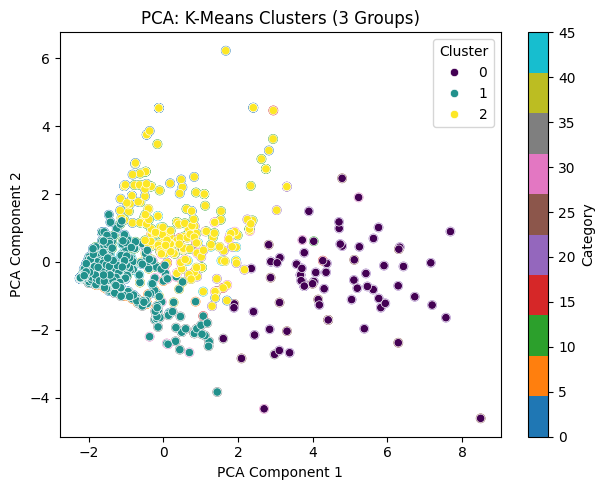

✅ PCA Visualization Complete. Clusters may group e.g., 'High-Protein' vs 'High-Carb' foods.


In [57]:
# Visualize PCA (2D Plot with Clusters - For Interpretation)
plt.figure(figsize=(12, 5))

# Subplot 1: PCA Scatter (Color by Category)
plt.subplot(1, 2, 1)
scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['Category'].astype('category').cat.codes, cmap='tab10')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA: Foods by Category')
plt.colorbar(scatter, label='Category')

# Subplot 2: Clusters (Optional KMeans on PCA)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis')
plt.title('PCA: K-Means Clusters (3 Groups)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

print("✅ PCA Visualization Complete. Clusters may group e.g., 'High-Protein' vs 'High-Carb' foods.")

In [59]:
# Save for Next Objective (Proposal: CI/CD Prep)
print("=== STEP 5: SAVE PRE-PROCESSED DATA & SUMMARY ===")

df.to_csv('preprocessed_nutri_data.csv', index=False)
print("✅ Preprocessed DataFrame saved to 'preprocessed_nutri_data.csv'")

# Safe Summary (Handles Missing Risk Columns)
summary = {
    'objective': 2,
    'shape_after': list(df.shape),  # Convert tuple to list for JSON
    'features_used': available_features if 'available_features' in locals() else numeric_features,  # From PCA Cell
    'pca_variance': pca.explained_variance_ratio_.tolist() if 'pca' in locals() else [0.0, 0.0]  # Fallback if PCA skipped
}

# Safe Deficiency Rates (Only for Created Risk Columns)
deficiency_rates = {}
for k in rda_thresholds.keys():
    risk_col = f'{k}_risk'
    if risk_col in df.columns:
        deficiency_rates[k] = df[risk_col].mean()
    else:
        print(f"⚠️ Skipping rate for {k} (column '{risk_col}' missing)")
        deficiency_rates[k] = 0.0  # Fallback: No deficiency detected

summary['deficiency_rates'] = deficiency_rates
print("Deficiency Rates Summary:")
for k, rate in deficiency_rates.items():
    print(f"  {k}: {rate:.2%}")

import json
with open('obj2_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n💾 Saved: preprocessed_nutri_data.csv & obj2_summary.json")
print("✅ Objective 2 SUCCESS! Ready for ML (Random Forest Classifier).")

=== STEP 5: SAVE PRE-PROCESSED DATA & SUMMARY ===
✅ Preprocessed DataFrame saved to 'preprocessed_nutri_data.csv'
⚠️ Skipping rate for Protein (g) (column 'Protein (g)_risk' missing)
⚠️ Skipping rate for Fiber (g) (column 'Fiber (g)_risk' missing)
⚠️ Skipping rate for Sodium (mg) (column 'Sodium (mg)_risk' missing)
⚠️ Skipping rate for Cholesterol (mg) (column 'Cholesterol (mg)_risk' missing)
Deficiency Rates Summary:
  Protein (g): 0.00%
  Fiber (g): 0.00%
  Sodium (mg): 0.00%
  Cholesterol (mg): 0.00%

💾 Saved: preprocessed_nutri_data.csv & obj2_summary.json
✅ Objective 2 SUCCESS! Ready for ML (Random Forest Classifier).
